# Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

# Load Datasets

In [ ]:
# Membaca data
df_gen = pd.read_csv('/datasets/raw/Plant_1_Generation_Data.csv')
df_weather = pd.read_csv('/datasets/raw/Plant_1_Weather_Sensor_Data.csv')

# Menyamakan format waktu
df_gen['DATE_TIME'] = pd.to_datetime(df_gen['DATE_TIME'])
df_weather['DATE_TIME'] = pd.to_datetime(df_weather['DATE_TIME'])

# Menggabungkan data generasi listrik dan cuaca
df_merged = pd.merge(df_gen, df_weather, on='DATE_TIME', how='inner')

# Menggabungkan output dari banyak inverter menjadi satu total per waktu
df_grouped = df_merged.groupby('DATE_TIME').agg({
    'AMBIENT_TEMPERATURE': 'mean',
    'MODULE_TEMPERATURE': 'mean',
    'IRRADIATION': 'mean',
    'DC_POWER': 'sum'
}).reset_index()

# Mengubah data dari per 15 menit menjadi per jam (Hourly)
df_grouped = df_grouped.sort_values('DATE_TIME')
df_grouped.set_index('DATE_TIME', inplace=True)
df_hourly = df_grouped.resample('H').mean().dropna()

print("Total baris data per jam:", len(df_hourly))

Total baris data per jam: 796


/tmp/ipykernel_1324/1286035308.py:6: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_gen['DATE_TIME'] = pd.to_datetime(df_gen['DATE_TIME'])
/tmp/ipykernel_1324/1286035308.py:23: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df_grouped.resample('H').mean().dropna()


# Preprocessing & Sequence

In [3]:
features = ['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']
target = ['DC_POWER']

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(df_hourly[features])
y_scaled = scaler_y.fit_transform(df_hourly[target])

# Menggunakan data 24 jam ke belakang untuk menebak 1 jam ke depan
LOOKBACK = 24

def create_sequences(X, y, time_steps):
    X_seq, y_seq = [], []
    for i in range(len(X) - time_steps):
        X_seq.append(X[i:(i + time_steps)])
        y_seq.append(y[i + time_steps])
    return np.array(X_seq), np.array(y_seq)

X_seq, y_seq = create_sequences(X_scaled, y_scaled, LOOKBACK)

# Membagi 80% data Train dan 20% data Test berurutan (TANPA SHUFFLE)
train_size = int(len(X_seq) * 0.8)

X_train_lstm = X_seq[:train_size]
y_train = y_seq[:train_size]
X_test_lstm = X_seq[train_size:]
y_test = y_seq[train_size:]

# Persiapan baseline & pelatihan model

In [4]:
# Meratakan data 3D menjadi 2D untuk model konvensional
X_train_flat = X_train_lstm.reshape(X_train_lstm.shape[0], -1)
X_test_flat = X_test_lstm.reshape(X_test_lstm.shape[0], -1)
y_train_flat = y_train.flatten()
y_test_flat = y_test.flatten()

print("1. Melatih Linear Regression...")
lr_model = LinearRegression()
lr_model.fit(X_train_flat, y_train_flat)
lr_pred_scaled = lr_model.predict(X_test_flat).reshape(-1, 1)

print("2. Melatih MLP...")
mlp_model = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
mlp_model.fit(X_train_flat, y_train_flat)
mlp_pred_scaled = mlp_model.predict(X_test_flat).reshape(-1, 1)

print("3. Melatih LSTM...")
lstm_model = Sequential([
    LSTM(32, input_shape=(LOOKBACK, len(features))),
    Dropout(0.2),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

lstm_model.fit(
    X_train_lstm, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.15,
    callbacks=[early_stop],
    shuffle=False,
    verbose=0
)
lstm_pred_scaled = lstm_model.predict(X_test_lstm)

1. Melatih Linear Regression...
2. Melatih MLP...
3. Melatih LSTM...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


# Evaluasi

In [6]:
# Mengembalikan nilai prediksi ke skala aslinya (Watt)
y_test_actual = scaler_y.inverse_transform(y_test)
lr_pred = scaler_y.inverse_transform(lr_pred_scaled)
mlp_pred = scaler_y.inverse_transform(mlp_pred_scaled)
lstm_pred = scaler_y.inverse_transform(lstm_pred_scaled)

def evaluate_model(name, actual, pred):
    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    r2 = r2_score(actual, pred)
    return [name, mae, rmse, r2]

results = [
    evaluate_model("Linear Regression", y_test_actual, lr_pred),
    evaluate_model("MLP", y_test_actual, mlp_pred),
    evaluate_model("LSTM (Proposed)", y_test_actual, lstm_pred)
]

results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2 Score"])

print("\n" + "─"*50)
print("HASIL AKHIR UNTUK POSTER ILMIAH:")
print("─"*50)
print(results_df.round(4).to_string(index=False))


──────────────────────────────────────────────────
HASIL AKHIR UNTUK POSTER ILMIAH:
──────────────────────────────────────────────────
            Model        MAE       RMSE  R2 Score
Linear Regression 17865.0277 24249.4421    0.9067
              MLP 17602.5183 24727.2622    0.9030
  LSTM (Proposed) 15326.9319 22806.5533    0.9174


# visualisasi

Grafik berhasil disimpan! 'grafik_poster_solarcast.png'


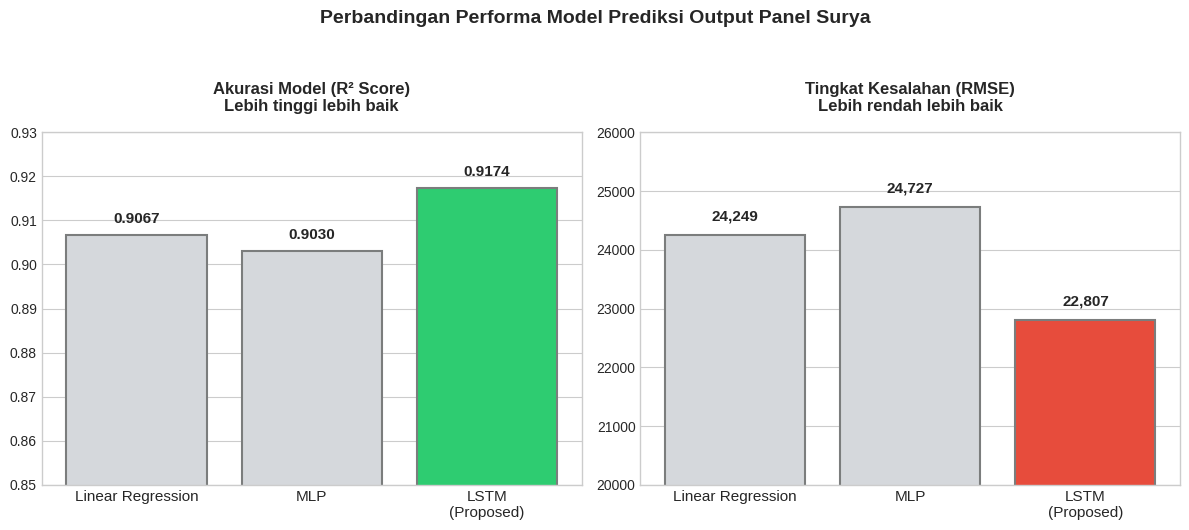

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Data dari hasil evaluasi
models = ['Linear Regression', 'MLP', 'LSTM\n(Proposed)']
r2_scores = [0.9067, 0.9030, 0.9174]
rmse_scores = [24249.44, 24727.26, 22806.55]

# Setting gaya grafik yang clean
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Palet Warna: Baseline = Abu-abu, LSTM = Warna Tegas
colors_r2 = ['#D5D8DC', '#D5D8DC', '#2ECC71']  # Hijau untuk R2
colors_rmse = ['#D5D8DC', '#D5D8DC', '#E74C3C'] # Merah untuk RMSE

# ─── Barchart 1: R2 Score ───
bars1 = ax1.bar(models, r2_scores, color=colors_r2, edgecolor='#7B7D7D', linewidth=1.5)
ax1.set_title('Akurasi Model (R² Score)\nLebih tinggi lebih baik', fontsize=12, fontweight='bold', pad=15)
ax1.set_ylim(0.85, 0.93) # Di-zoom biar perbedaan bar-nya kelihatan jelas
ax1.tick_params(axis='x', labelsize=11)
ax1.grid(axis='x') # Hilangkan garis grid vertikal biar bersih

# Tambah angka di atas bar R2
for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 0.002,
             f'{yval:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# ─── Barchart 2: RMSE ───
bars2 = ax2.bar(models, rmse_scores, color=colors_rmse, edgecolor='#7B7D7D', linewidth=1.5)
ax2.set_title('Tingkat Kesalahan (RMSE)\nLebih rendah lebih baik', fontsize=12, fontweight='bold', pad=15)
ax2.set_ylim(20000, 26000)
ax2.tick_params(axis='x', labelsize=11)
ax2.grid(axis='x')

# Tambah angka di atas bar RMSE
for bar in bars2:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 200,
             f'{yval:,.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.suptitle('Perbandingan Performa Model Prediksi Output Panel Surya', fontsize=14, fontweight='heavy', y=1.05)
plt.tight_layout()

# Simpan sebagai file PNG resolusi tinggi (300 dpi sangat tajam untuk dicetak di poster)
plt.savefig('grafik_poster_solarcast.png', dpi=300, bbox_inches='tight', transparent=True)
print("Grafik berhasil disimpan! 'grafik_poster_solarcast.png'")